In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt


In [3]:
# Reproducible simulation
np.random.seed(42)

In [4]:
n_control = 20000
n_treatment = 20000

In [5]:
# True baseline: Control = 12.0% conversion, Treatment = 13.1% conversion (+1.1pp lift)
control_conversions = np.random.binomial(1, 0.120, n_control)
treatment_conversions = np.random.binomial(1, 0.131, n_treatment)

In [10]:
control_conversions

array([0, 1, 0, ..., 0, 0, 0], shape=(20000,), dtype=int32)

In [11]:
treatment_conversions

array([0, 0, 0, ..., 0, 0, 0], shape=(20000,), dtype=int32)

In [6]:
df_control = pd.DataFrame({
    'user_id': range(100000, 100000 + n_control),
    'group': 'control',
    'converted': control_conversions
})
df_treatment = pd.DataFrame({
    'user_id': range(100000 + n_control, 100000 + n_control + n_treatment),
    'group': 'treatment',
    'converted': treatment_conversions
})

In [8]:
df_control

,user_id,group,converted
0,100000,control,0
1,100001,control,1
2,100002,control,0
3,100003,control,0
4,100004,control,0
...,...,...,...
19995,119995,control,0
19996,119996,control,0
19997,119997,control,0
19998,119998,control,0


In [9]:
df_treatment

,user_id,group,converted
0,120000,treatment,0
1,120001,treatment,0
2,120002,treatment,0
3,120003,treatment,0
4,120004,treatment,0
...,...,...,...
19995,139995,treatment,0
19996,139996,treatment,0
19997,139997,treatment,0
19998,139998,treatment,0


In [7]:
ab_df = pd.concat([df_control, df_treatment]).sample(frac=1).reset_index(drop=True)
ab_df.head()

,user_id,group,converted
0,134234,treatment,0
1,130584,treatment,1
2,109368,control,0
3,118516,control,0
4,124850,treatment,1


### SRM

In [12]:
observed = ab_df['group'].value_counts()
total_visitors = observed.sum()
expected = [total_visitors / 2, total_visitors / 2]

chi2_stat, srm_p_value = stats.chisquare(f_obs=observed, f_exp=expected)

print(f"Observed Counts:\n{observed}\n")
print(f"SRM Chi-Square Stat: {chi2_stat:.4f} | p-value: {srm_p_value:.4f}")

if srm_p_value < 0.01:
    print("WARNING: Sample Ratio Mismatch detected!")
else:
    print("SRM Check Passed: sample split is valid.")

Observed Counts:
group
treatment    20000
control      20000
Name: count, dtype: int64

SRM Chi-Square Stat: 0.0000 | p-value: 1.0000
SRM Check Passed: sample split is valid.


In [13]:
conversion_summary = ab_df.groupby('group')['converted'].agg(['count', 'sum', 'mean']).rename(
    columns={'count': 'total_users', 'sum': 'conversions', 'mean': 'conversion_rate'}
)
conversion_summary['conversion_rate_pct'] = conversion_summary['conversion_rate'] * 100
print(conversion_summary)

           total_users  conversions  conversion_rate  conversion_rate_pct
group                                                                    
control          20000         2394           0.1197                11.97
treatment        20000         2578           0.1289                12.89


In [14]:
control_n = conversion_summary.loc['control', 'total_users']
control_n

np.int64(20000)

In [15]:
control_conv = conversion_summary.loc['control', 'conversions']
control_conv

np.int32(2394)

In [16]:
treatment_n = conversion_summary.loc['treatment', 'total_users']
treatment_n

np.int64(20000)

In [17]:
treatment_conv = conversion_summary.loc['treatment', 'conversions']
treatment_conv

np.int32(2578)

In [18]:
p_control = control_conv / control_n
p_treatment = treatment_conv / treatment_n

In [19]:
# Pooled proportion under H0 (no difference)
p_pooled = (control_conv + treatment_conv) / (control_n + treatment_n)

In [20]:
# Standard error under pooled assumption
se_pooled = np.sqrt(p_pooled * (1 - p_pooled) * (1/control_n + 1/treatment_n))

In [21]:
# Z-statistic
z_stat = (p_treatment - p_control) / se_pooled

# Two-tailed p-value
p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))

In [22]:
print(f"Control conversion rate: {p_control*100:.2f}%")
print(f"Treatment conversion rate: {p_treatment*100:.2f}%")
print(f"Observed lift: {(p_treatment - p_control)*100:.2f} pp")
print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value: {p_value:.4f}")

Control conversion rate: 11.97%
Treatment conversion rate: 12.89%
Observed lift: 0.92 pp
Z-statistic: 2.7885
P-value: 0.0053


In [23]:
# Unpooled SE for the confidence interval (standard practice: pooled for the test, unpooled for the CI)
se_unpooled = np.sqrt((p_control*(1-p_control))/control_n + (p_treatment*(1-p_treatment))/treatment_n)

diff = p_treatment - p_control
ci_lower = diff - 1.96 * se_unpooled
ci_upper = diff + 1.96 * se_unpooled

print(f"95% CI for the difference in conversion rates: [{ci_lower*100:.2f}pp, {ci_upper*100:.2f}pp]")

95% CI for the difference in conversion rates: [0.27pp, 1.57pp]


Saved: ab_test_results.png


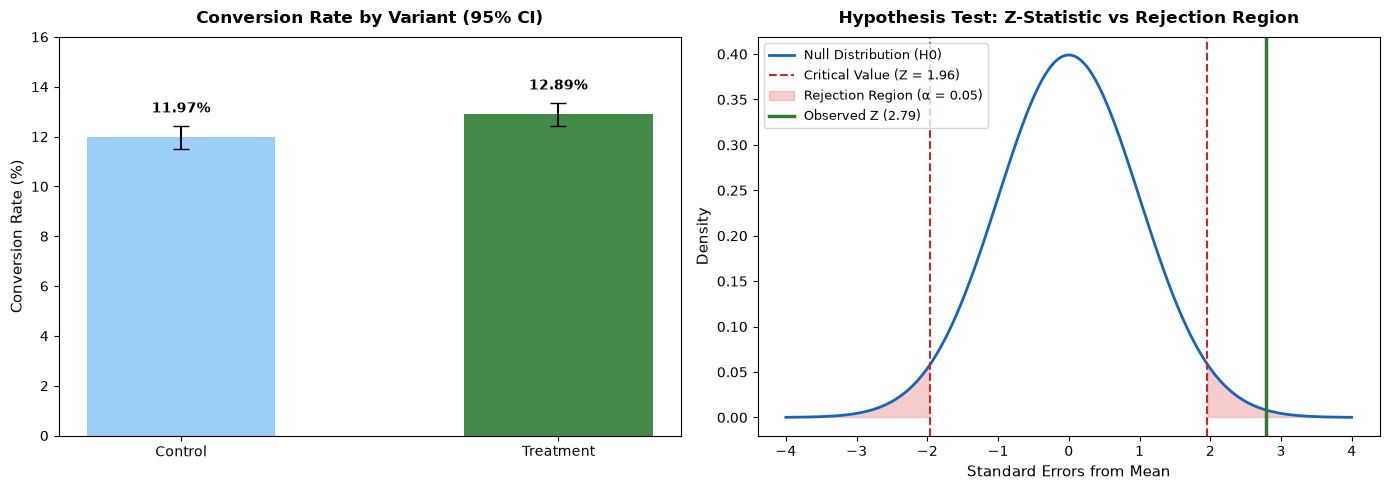

In [25]:
import os

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 1. Bar Chart: Conversion Rates with 95% CI Error Bars
groups = ['Control', 'Treatment']
rates = [p_control * 100, p_treatment * 100]
ci_errors = [
    1.96 * np.sqrt((p_control * (1 - p_control)) / control_n) * 100,
    1.96 * np.sqrt((p_treatment * (1 - p_treatment)) / treatment_n) * 100
]

bars = ax1.bar(groups, rates, yerr=ci_errors, capsize=6, color=['#90caf9', '#2e7d32'], width=0.5, alpha=0.9)
ax1.set_ylabel('Conversion Rate (%)', fontsize=11)
ax1.set_ylim(0, 16)
ax1.set_title('Conversion Rate by Variant (95% CI)', fontsize=12, fontweight='bold', pad=10)

for bar, rate in zip(bars, rates):
    ax1.text(bar.get_x() + bar.get_width() / 2, rate + 1.0, f"{rate:.2f}%", ha='center', fontweight='bold')

# 2. Distribution Plot: Standard Normal Curve & Z-Score
x = np.linspace(-4, 4, 1000)
y = stats.norm.pdf(x)
ax2.plot(x, y, color='#1565c0', lw=2, label='Null Distribution (H0)')

# Critical threshold (alpha = 0.05, two-tailed -> z = 1.96)
z_crit = 1.96
ax2.axvline(z_crit, color='#c62828', linestyle='--', label=f'Critical Value (Z = {z_crit})')
ax2.axvline(-z_crit, color='#c62828', linestyle='--')

# Fill rejection regions
ax2.fill_between(x, 0, y, where=(x >= z_crit) | (x <= -z_crit), color='#ef9a9a', alpha=0.5, label='Rejection Region (α = 0.05)')

# Plot observed test statistic
ax2.axvline(z_stat, color='#2e7d32', lw=2.5, label=f'Observed Z ({z_stat:.2f})')
ax2.set_title('Hypothesis Test: Z-Statistic vs Rejection Region', fontsize=12, fontweight='bold', pad=10)
ax2.set_xlabel('Standard Errors from Mean', fontsize=11)
ax2.set_ylabel('Density', fontsize=11)
ax2.legend(loc='upper left', fontsize=9)

plt.tight_layout()

# Fix: always save, no existence check needed
plt.savefig('ab_test_results.png', dpi=300, bbox_inches='tight')
print("Saved: ab_test_results.png")

plt.show()

## Decision Framework: Should the Treatment Ship?

### 1. Statistical Significance: Confirmed (Reject H0)

* **Hypothesis Result:** The observed conversion lift from **11.97% to 12.89% (+0.92 pp)** is statistically significant ($Z = 2.79, p = 0.0053 < \alpha = 0.05$).
* **Confidence Bounds:** The 95% Confidence Interval for the difference is **[+0.27 pp, +1.57 pp]**. Because the interval lies entirely above zero, there is negligible risk of a negative conversion impact under normal operational conditions.
* **Integrity Validation:** The Sample Ratio Mismatch (SRM) test showed no traffic allocation bias ($\chi^2 = 0.0000, p = 1.0000$), confirming the random split mechanism remained uncompromised.

### 2. Practical Significance & Economic Impact

Statistical significance confirms an effect exists; practical significance determines if it pays for itself. *(Note: the user base and break-even figures below are illustrative assumptions for scaling purposes, not values derived from the experiment data itself — in practice these would come from actual traffic figures and engineering cost estimates.)*

* **Assumed MDE Hurdle:** Assuming an illustrative engineering and operational break-even threshold of **+0.50 pp** (a ~4.2% relative lift):
  * **Pessimistic Scenario (CI Lower Bound = +0.27 pp):** At a hypothetical 100,000 monthly active users, this yields **+270 incremental conversions/month** (+2.3% relative lift). This may not justify heavy recurring maintenance costs.
  * **Expected Scenario (Point Estimate = +0.92 pp):** At 100,000 monthly active users, this yields **+920 incremental conversions/month** (+7.7% relative lift), representing substantial added value.
  * **Optimistic Scenario (CI Upper Bound = +1.57 pp):** At 100,000 monthly active users, this yields **+1,570 incremental conversions/month** (+13.1% relative lift).

### 3. Executive Recommendation: SHIP TO PRODUCTION

**Decision: Deploy Treatment to 100% Traffic**, subject to standard phased rollout guardrails:

1. **Phased Rollout:** Ramp allocation from 50% → 75% → 100% over 5–7 business days while monitoring baseline secondary metrics (e.g., page load latency, average order value, server error rates).
2. **Novelty Effect Audit:** Measure retention and conversion cohorts at Day 14 and Day 30 post-launch to verify that the +0.92 pp lift remains stable and was not an artifact of short-term user curiosity.
3. **Segment Health:** Validate whether lift holds consistently across key dimensions (e.g., Mobile vs. Desktop, New vs. Returning visitors) prior to fully deprecating the Control design.

### 4. Analytical Caveats

This analysis assumes a single, clean binary conversion metric, a fixed test window with no interaction effects, and no segment-level heterogeneity in the treatment effect. Real-world rollouts can see effects regress toward zero (a novelty-effect false positive) or grow over time (compounding/network effects) once initial user reactivity fades — which is precisely why the Novelty Effect Audit and Segment Health checks above are included as rollout conditions rather than optional follow-ups.

### Real Data Set

In [30]:
real_df = pd.read_csv('ab_data.csv')
print(real_df.shape)
print(real_df.head())

(294478, 5)
   user_id                   timestamp      group landing_page  converted
0   851104  2017-01-21 22:11:48.556739    control     old_page          0
1   804228  2017-01-12 08:01:45.159739    control     old_page          0
2   661590  2017-01-11 16:55:06.154213  treatment     new_page          0
3   853541  2017-01-08 18:28:03.143765  treatment     new_page          0
4   864975  2017-01-21 01:52:26.210827    control     old_page          1


In [27]:
print(real_df['group'].value_counts())


group
treatment    147276
control      147202
Name: count, dtype: int64


In [28]:
print(real_df['user_id'].duplicated().sum())  # check for duplicate users across groups — known issue in this dataset

3894


In [29]:
dupe_ids = real_df[real_df.duplicated('user_id', keep=False)]['user_id'].unique()
real_df_clean = real_df[~real_df['user_id'].isin(dupe_ids)]
print(f"Dropped {len(dupe_ids)} users present in both groups")

Dropped 3894 users present in both groups


In [31]:
mismatch = real_df_clean[
    ((real_df_clean['group'] == 'control') & (real_df_clean['landing_page'] == 'new_page')) |
    ((real_df_clean['group'] == 'treatment') & (real_df_clean['landing_page'] == 'old_page'))
]
print(f"Mismatched group/page rows: {len(mismatch)}")

Mismatched group/page rows: 0


In [32]:
real_df_clean = real_df_clean[~real_df_clean.index.isin(mismatch.index)]
print(f"Final clean dataset size: {len(real_df_clean)}")

Final clean dataset size: 286690


In [33]:
real_conversion_summary = real_df_clean.groupby('group')['converted'].agg(['count', 'sum', 'mean']).rename(
    columns={'count': 'total_users', 'sum': 'conversions', 'mean': 'conversion_rate'}
)
real_conversion_summary['conversion_rate_pct'] = real_conversion_summary['conversion_rate'] * 100
print(real_conversion_summary)

           total_users  conversions  conversion_rate  conversion_rate_pct
group                                                                    
control         143293        17220         0.120173            12.017335
treatment       143397        17025         0.118726            11.872633


In [34]:
# SRM check on real, cleaned data
observed_real = real_df_clean['group'].value_counts()
total_real = observed_real.sum()
expected_real = [total_real / 2, total_real / 2]

chi2_stat_real, srm_p_value_real = stats.chisquare(f_obs=observed_real, f_exp=expected_real)

print(f"Observed Counts:\n{observed_real}\n")
print(f"SRM Chi-Square Stat: {chi2_stat_real:.4f} | p-value: {srm_p_value_real:.4f}")

if srm_p_value_real < 0.01:
    print("WARNING: Sample Ratio Mismatch detected!")
else:
    print("SRM Check Passed: sample split is valid.")

Observed Counts:
group
treatment    143397
control      143293
Name: count, dtype: int64

SRM Chi-Square Stat: 0.0377 | p-value: 0.8460
SRM Check Passed: sample split is valid.


In [35]:
# STEP 6: Pooled two-proportion Z-test
control_n_r = real_conversion_summary.loc['control', 'total_users']
control_conv_r = real_conversion_summary.loc['control', 'conversions']
treatment_n_r = real_conversion_summary.loc['treatment', 'total_users']
treatment_conv_r = real_conversion_summary.loc['treatment', 'conversions']

p_control_r = control_conv_r / control_n_r
p_treatment_r = treatment_conv_r / treatment_n_r

# Pooled proportion under H0
p_pooled_r = (control_conv_r + treatment_conv_r) / (control_n_r + treatment_n_r)

# Standard error (pooled)
se_pooled_r = np.sqrt(p_pooled_r * (1 - p_pooled_r) * (1/control_n_r + 1/treatment_n_r))

# Z-statistic and two-tailed p-value
z_stat_r = (p_treatment_r - p_control_r) / se_pooled_r
p_value_r = 2 * (1 - stats.norm.cdf(abs(z_stat_r)))

print(f"Control conversion rate: {p_control_r*100:.3f}%")
print(f"Treatment conversion rate: {p_treatment_r*100:.3f}%")
print(f"Observed lift: {(p_treatment_r - p_control_r)*100:.3f} pp")
print(f"Z-statistic: {z_stat_r:.4f}")
print(f"P-value: {p_value_r:.4f}")

Control conversion rate: 12.017%
Treatment conversion rate: 11.873%
Observed lift: -0.145 pp
Z-statistic: -1.1945
P-value: 0.2323


In [37]:
# STEP 7: 95% Confidence Interval on the difference (unpooled)
se_unpooled_r = np.sqrt(
    (p_control_r*(1-p_control_r))/control_n_r + (p_treatment_r*(1-p_treatment_r))/treatment_n_r
)

diff_r = p_treatment_r - p_control_r
ci_lower_r = diff_r - 1.96 * se_unpooled_r
ci_upper_r = diff_r + 1.96 * se_unpooled_r

print(f"95% CI for the difference in conversion rates: [{ci_lower_r*100:.3f}pp, {ci_upper_r*100:.3f}pp]")

95% CI for the difference in conversion rates: [-0.382pp, 0.093pp]


Saved: ab_test_results_realdata.png


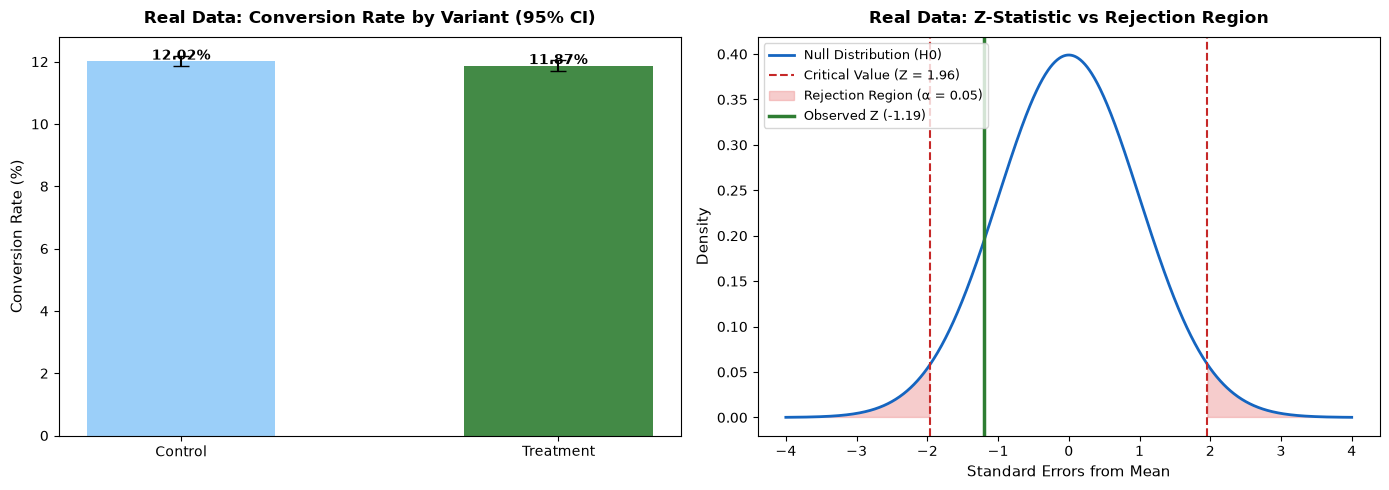

In [38]:
# STEP 8: Visualization — bar chart + null distribution
# ============================================================
import os

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Panel 1: Conversion rate bar chart with 95% CI error bars ---
groups_r = ['Control', 'Treatment']
rates_r = [p_control_r * 100, p_treatment_r * 100]
ci_errors_r = [
    1.96 * np.sqrt((p_control_r * (1 - p_control_r)) / control_n_r) * 100,
    1.96 * np.sqrt((p_treatment_r * (1 - p_treatment_r)) / treatment_n_r) * 100
]

bars_r = ax1.bar(groups_r, rates_r, yerr=ci_errors_r, capsize=6,
                  color=['#90caf9', '#2e7d32'], width=0.5, alpha=0.9)
ax1.set_ylabel('Conversion Rate (%)', fontsize=11)
ax1.set_title('Real Data: Conversion Rate by Variant (95% CI)', fontsize=12, fontweight='bold', pad=10)
for bar, rate in zip(bars_r, rates_r):
    ax1.text(bar.get_x() + bar.get_width() / 2, rate + 0.05, f"{rate:.2f}%", ha='center', fontweight='bold')

# --- Panel 2: Null distribution with observed Z ---
x = np.linspace(-4, 4, 1000)
y = stats.norm.pdf(x)
ax2.plot(x, y, color='#1565c0', lw=2, label='Null Distribution (H0)')

z_crit = 1.96
ax2.axvline(z_crit, color='#c62828', linestyle='--', label=f'Critical Value (Z = {z_crit})')
ax2.axvline(-z_crit, color='#c62828', linestyle='--')
ax2.fill_between(x, 0, y, where=(x >= z_crit) | (x <= -z_crit),
                  color='#ef9a9a', alpha=0.5, label='Rejection Region (α = 0.05)')
ax2.axvline(z_stat_r, color='#2e7d32', lw=2.5, label=f'Observed Z ({z_stat_r:.2f})')

ax2.set_title('Real Data: Z-Statistic vs Rejection Region', fontsize=12, fontweight='bold', pad=10)
ax2.set_xlabel('Standard Errors from Mean', fontsize=11)
ax2.set_ylabel('Density', fontsize=11)
ax2.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig('ab_test_results_realdata.png', dpi=300, bbox_inches='tight')
print("Saved: ab_test_results_realdata.png")
plt.show()

## Synthetic vs. Real Data: Comparing Results

The same testing pipeline (SRM check → pooled Z-test → unpooled CI) was applied
to two datasets: a synthetic experiment with a known, designed-in +1.1pp lift,
and a real-world dataset of 286K+ users.

| | Synthetic Data | Real Data (ab_data.csv) |
|---|---|---|
| Sample size (per group) | 20,000 | ~143,300 |
| Observed lift | +0.92pp | **-0.145pp** |
| Z-statistic | 2.79 | -1.19 |
| P-value | 0.0053 | 0.2323 |
| 95% CI | [0.27pp, 1.57pp] | [-0.38pp, 0.09pp] |
| Decision | Ship | **Do not ship** |

The synthetic test validated that the pipeline correctly detects a real effect
when one exists — the recovered lift (0.92pp) closely matched the designed
true effect (1.1pp), and the test correctly rejected H0. The real dataset,
by contrast, shows no statistically significant difference between variants,
and the point estimate is actually slightly negative. This is a useful
real-world contrast: not every experiment finds a winner, and a well-powered
test with a large sample size returning a null result is itself a valid,
actionable business finding — it prevents shipping a change that offers no
benefit (and here, plausibly a small regression) at real engineering cost.